In [1]:
import numpy as np 
import pandas as pd 
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("earthquakes_2023_global.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26642 entries, 0 to 26641
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             26642 non-null  object 
 1   latitude         26642 non-null  float64
 2   longitude        26642 non-null  float64
 3   depth            26642 non-null  float64
 4   mag              26642 non-null  float64
 5   magType          26642 non-null  object 
 6   nst              25227 non-null  float64
 7   gap              25225 non-null  float64
 8   dmin             24776 non-null  float64
 9   rms              26642 non-null  float64
 10  net              26642 non-null  object 
 11  id               26642 non-null  object 
 12  updated          26642 non-null  object 
 13  place            25034 non-null  object 
 14  type             26642 non-null  object 
 15  horizontalError  25093 non-null  float64
 16  depthError       26642 non-null  float64
 17  magError    

In [4]:
df.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource'],
      dtype='object')

In [6]:
#checking missing values
df.isnull().sum()

time                  0
latitude              0
longitude             0
depth                 0
mag                   0
magType               0
nst                1415
gap                1417
dmin               1866
rms                   0
net                   0
id                    0
updated               0
place              1608
type                  0
horizontalError    1549
depthError            0
magError           1672
magNst             1577
status                0
locationSource        0
magSource             0
dtype: int64

In [7]:
#check duplicate values
df.duplicated().sum()

1960

In [8]:
duplicates = df[df.duplicated()]
print("Number of duplicate rows:", len(duplicates))

Number of duplicate rows: 1960


In [9]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [10]:
# Verify that duplicates have been removed
print("Number of duplicate rows after removal:", len(df[df.duplicated()]))

Number of duplicate rows after removal: 0


In [11]:
# fill the null value
df['nst'].fillna(df['nst'].mean(), inplace=True)
df['gap'].fillna(df['gap'].mean(), inplace=True)
df['dmin'].fillna(df['dmin'].mean(), inplace=True)
df['horizontalError'].fillna(df['horizontalError'].mean(), inplace=True)
df['magError'].fillna(df['magError'].mean(), inplace=True)
df['magNst'].fillna(df['magNst'].mean(), inplace=True)

In [12]:
# For 'place' column, fill missing values with 'Unknown'
df['place'].fillna('Unknown', inplace=True)

In [13]:
# Display the remaining missing values after handling
print(df.isnull().sum())

time               0
latitude           0
longitude          0
depth              0
mag                0
magType            0
nst                0
gap                0
dmin               0
rms                0
net                0
id                 0
updated            0
place              0
type               0
horizontalError    0
depthError         0
magError           0
magNst             0
status             0
locationSource     0
magSource          0
dtype: int64


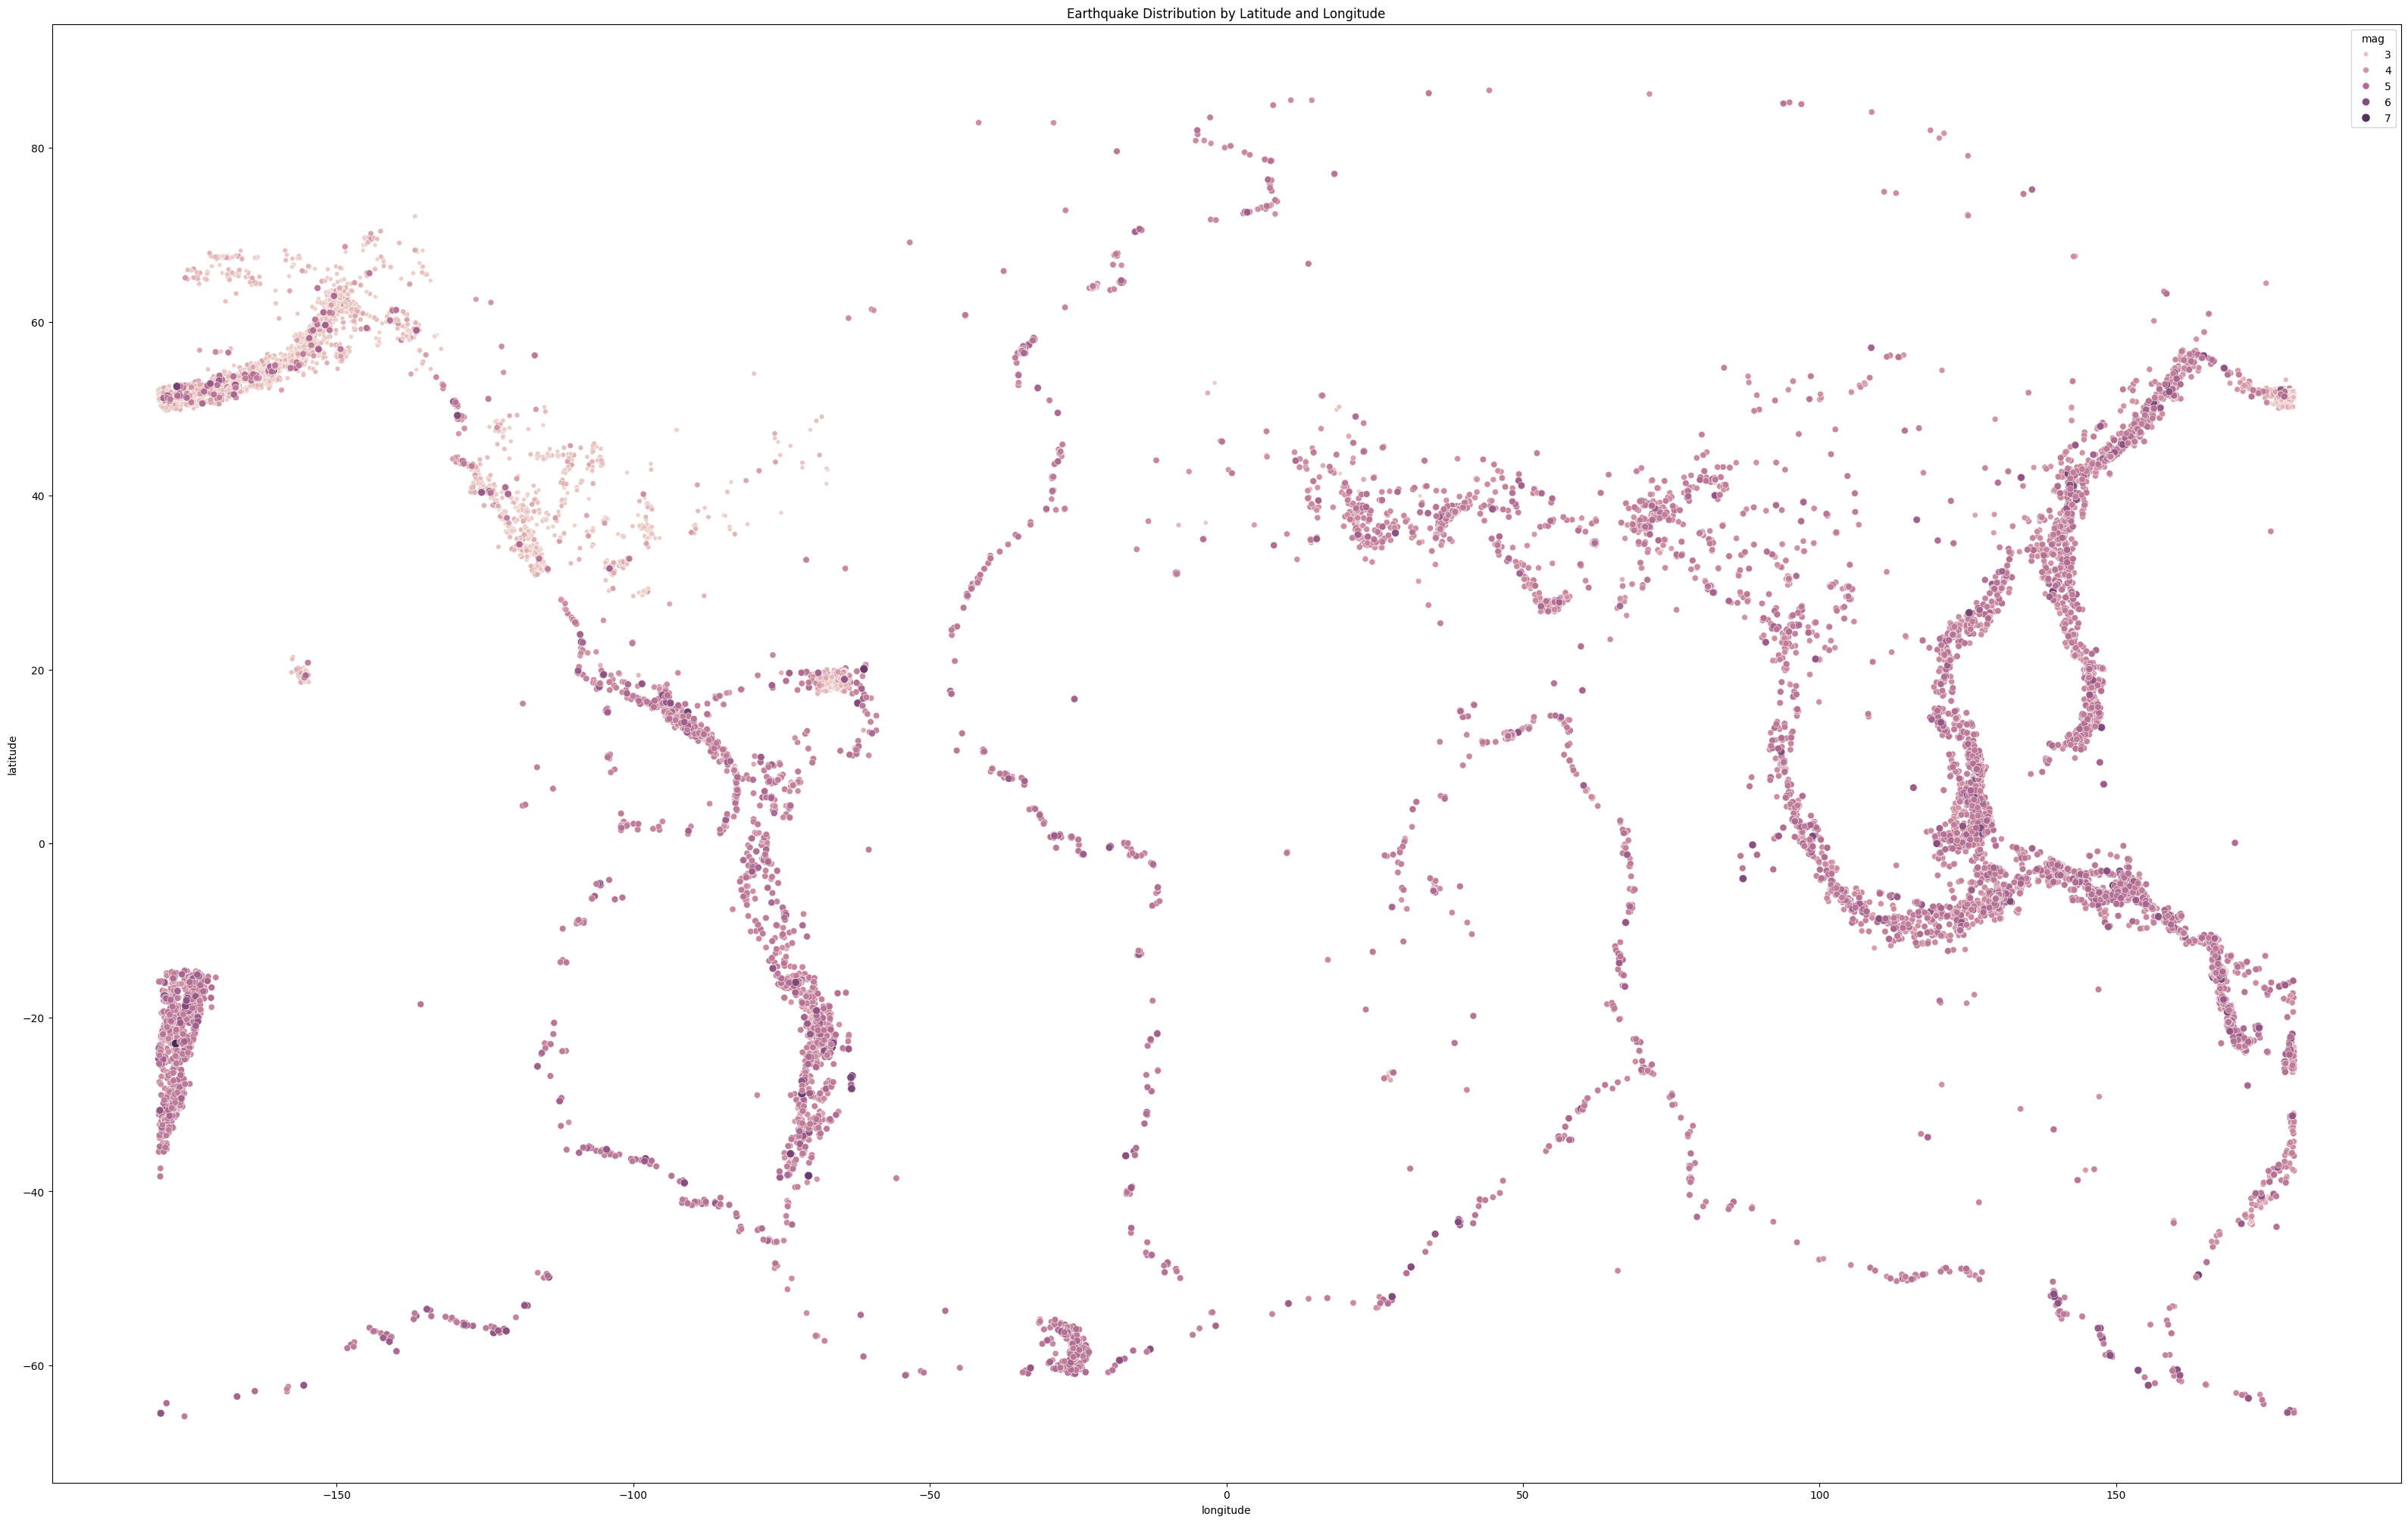

In [14]:
# Spatial Analysis
plt.figure(figsize=(40, 25))
sns.scatterplot(x='longitude', y='latitude', hue='mag', size='mag', data=df)
plt.title('Earthquake Distribution by Latitude and Longitude')
plt.show()

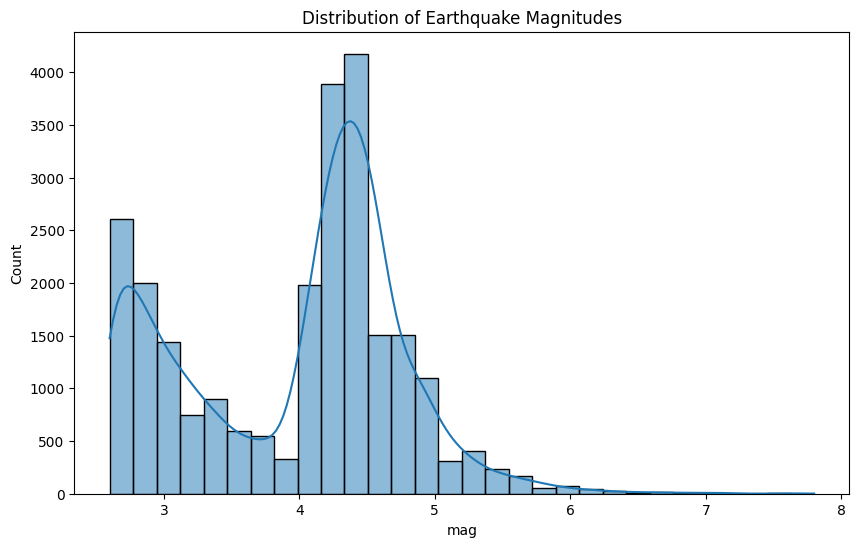

In [15]:
# Magnitude Analysis
plt.figure(figsize=(10, 6))
sns.histplot(df['mag'], bins=30, kde=True)
plt.title('Distribution of Earthquake Magnitudes')
plt.show()

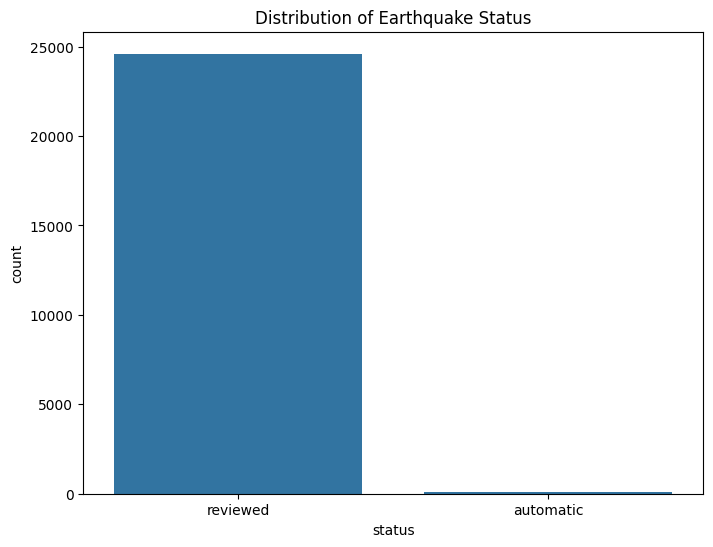

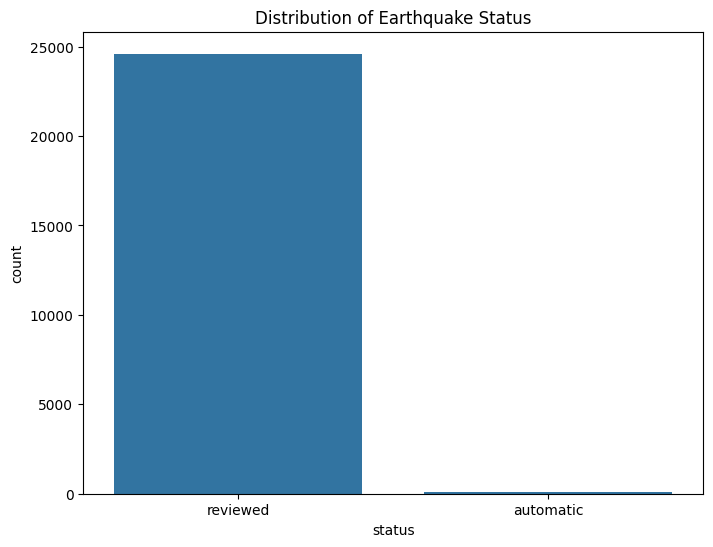

In [16]:
# Status Analysis
plt.figure(figsize=(8, 6))
sns.countplot(x='status', data=df)
plt.title('Distribution of Earthquake Status')
plt.show()# Status Analysis
plt.figure(figsize=(8, 6))
sns.countplot(x='status', data=df)
plt.title('Distribution of Earthquake Status')
plt.show()

In [18]:
from mpl_toolkits.basemap import Basemap

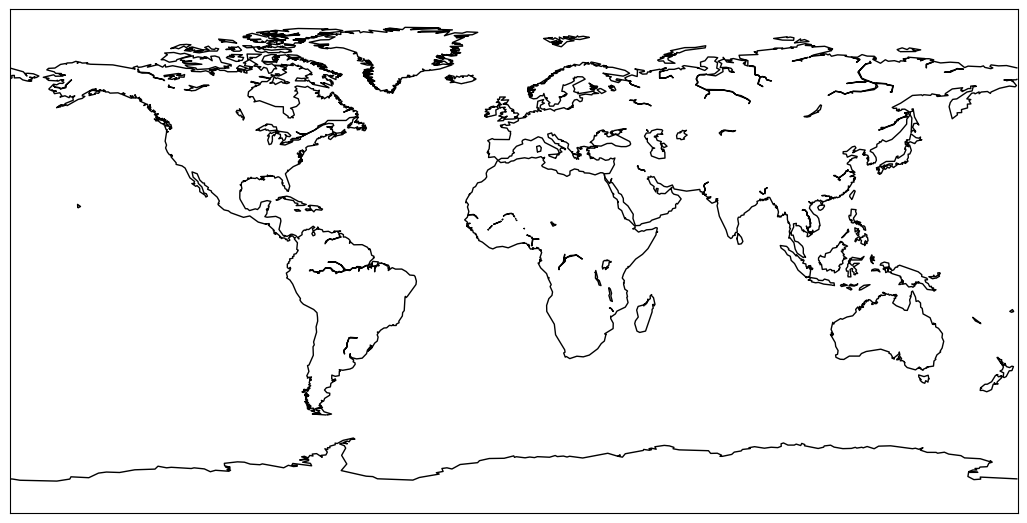

In [19]:
plt.rcParams["figure.figsize"]=13,13
m=Basemap()
m.drawcoastlines()
 
plt.show();

In [20]:
lats = df['latitude'].values
lons = df['longitude'].values
magnitudes = df['mag'].values

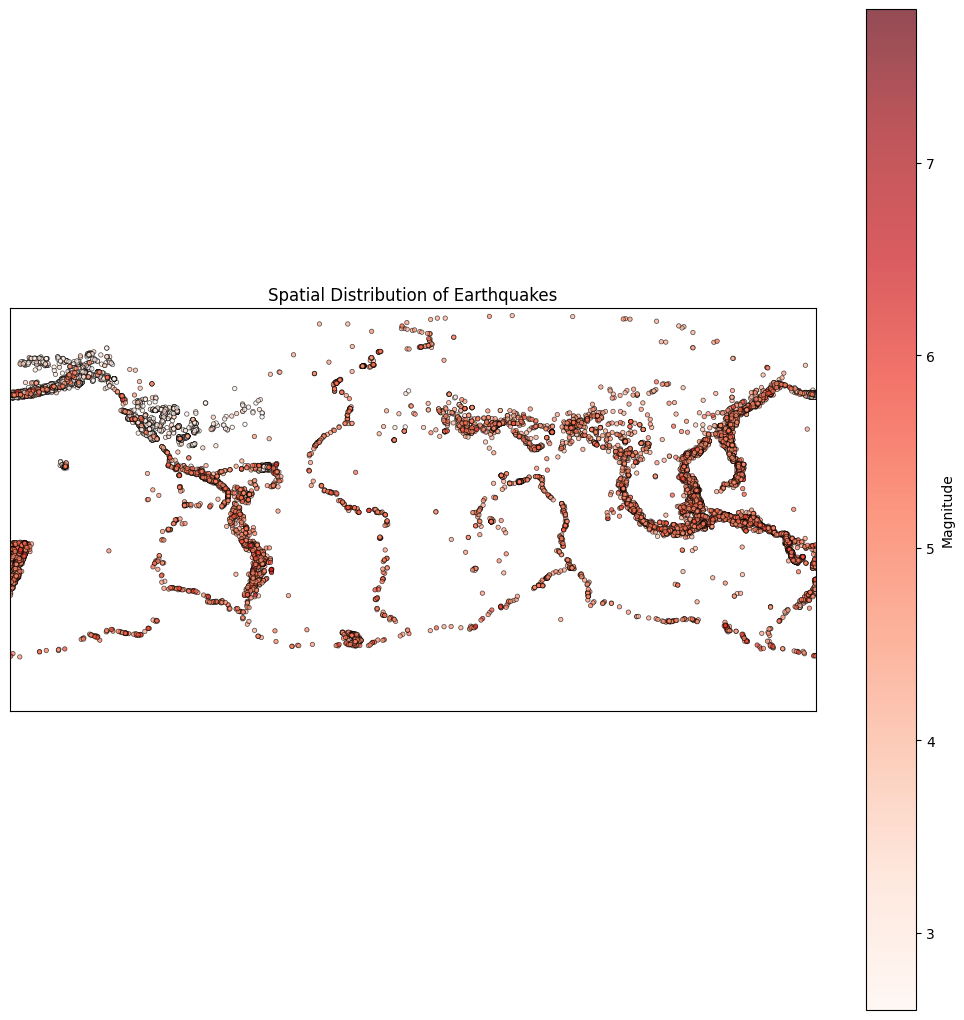

In [21]:
# Scatter plot earthquake locations on the map
x, y = m(lons, lats)
m.scatter(x, y, c=magnitudes, s=10, cmap='Reds', alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(label='Magnitude')
plt.title('Spatial Distribution of Earthquakes')
plt.show()

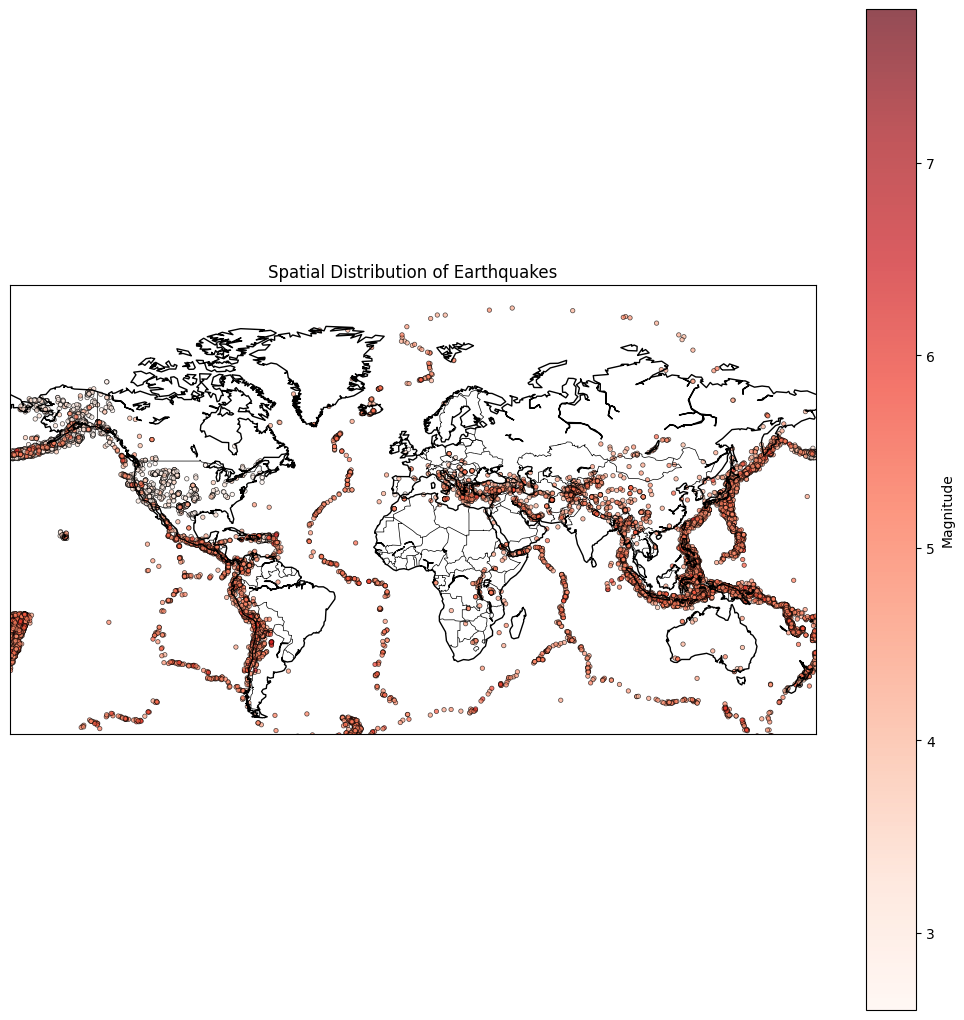

In [22]:
plt.rcParams["figure.figsize"] = 13, 13
m = Basemap(projection='mill', llcrnrlat=-60, urcrnrlat=90, llcrnrlon=-180, urcrnrlon=180, resolution='c')
m.drawcoastlines()
m.drawcountries()
# Scatter plot earthquake locations on the map
x, y = m(lons, lats)
m.scatter(x, y, c=magnitudes, s=10, cmap='Reds', alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(label='Magnitude')
plt.title('Spatial Distribution of Earthquakes')
plt.show()

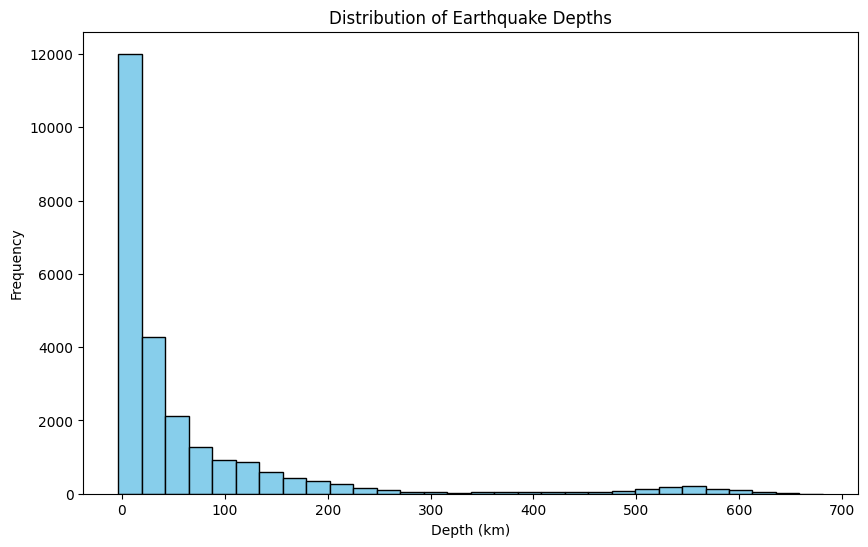

In [23]:
# earthquake depth analysis
plt.figure(figsize=(10, 6))
plt.hist(df['depth'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Earthquake Depths')
plt.xlabel('Depth (km)')
plt.ylabel('Frequency')
plt.show()

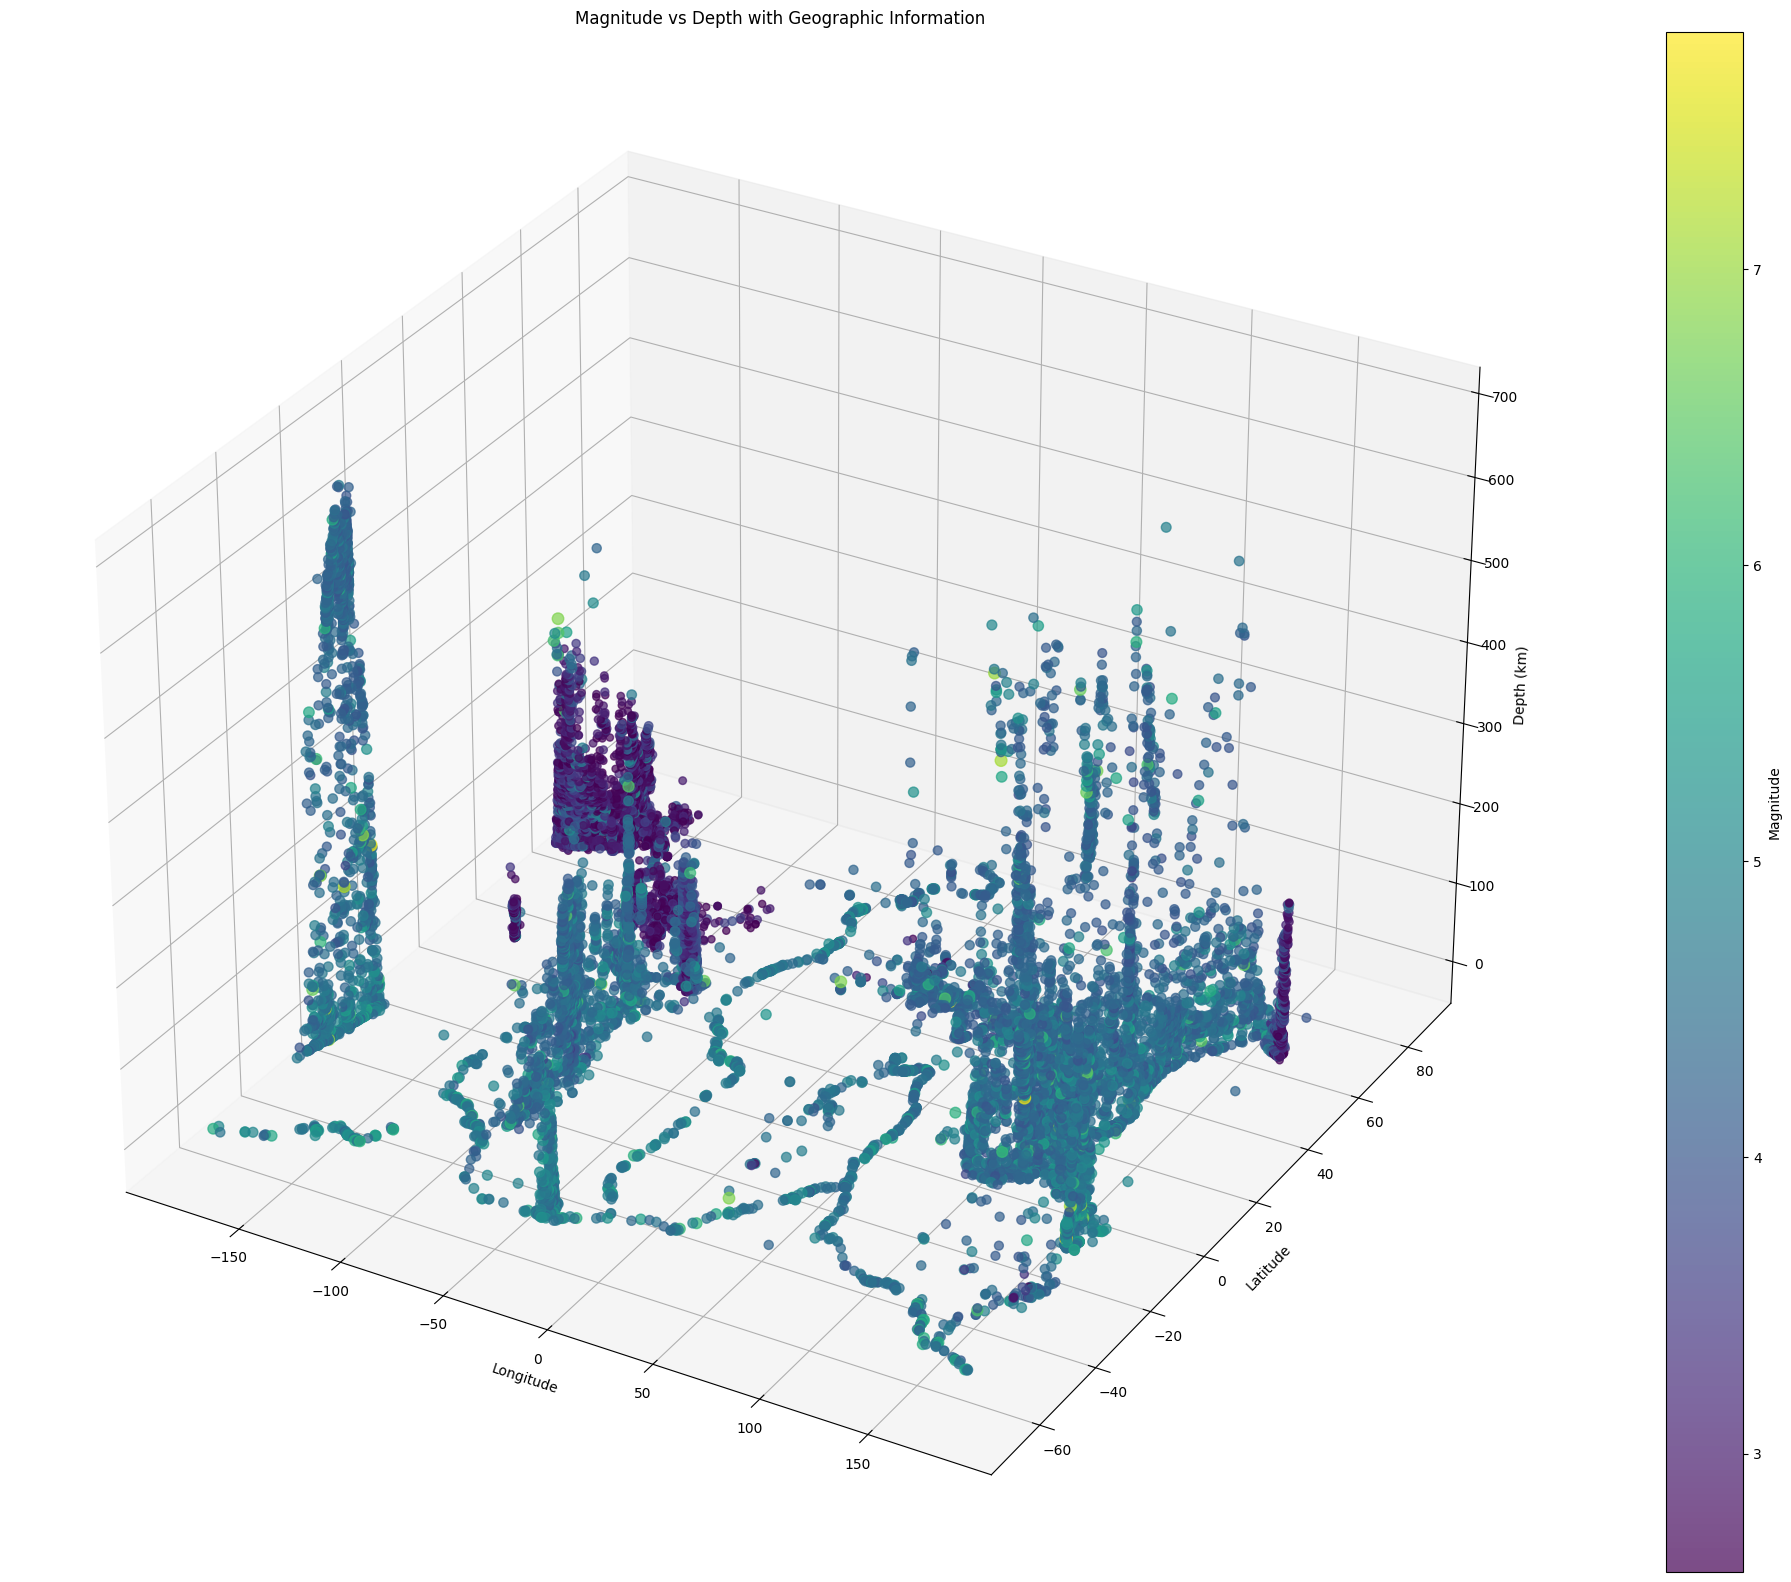

In [24]:
# magnitude vs depth analysis
fig = plt.figure(figsize=(30, 20))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['longitude'], df['latitude'], df['depth'], c=df['mag'], cmap='viridis', s=df['mag']*10, alpha=0.7)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Depth (km)')
ax.set_title('Magnitude vs Depth with Geographic Information')
cbar = plt.colorbar(scatter)
cbar.set_label('Magnitude')

plt.show()

<Figure size 2500x2000 with 0 Axes>

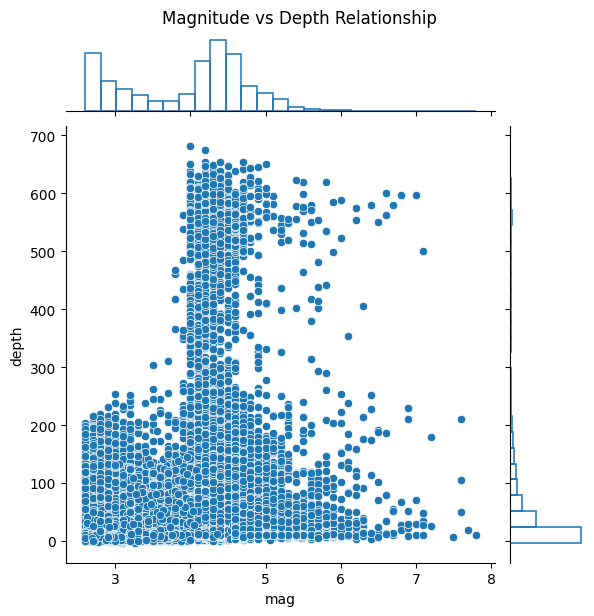

In [25]:
plt.figure(figsize=(25, 20))
sns.jointplot(x='mag', y='depth', data=df, kind='scatter', marginal_kws=dict(bins=25, fill=False))
plt.suptitle('Magnitude vs Depth Relationship', y=1.02)
plt.show()